# Experiment 4
## Comparative Study of RNN Variants for Time-Series Forecasting

**Objective:** To perform a comparative study of RNN variants for time-series forecasting.

**Models being compared:**
1. Simple RNN
2. LSTM
3. GRU

**Evaluation metrics:**
* MAE
* MSE
* RMSE
* Training Time


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

### 3. Load Dataset

In [2]:
df = pd.read_csv("temperature_timeseries_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"], format='mixed', dayfirst=True)
display(df.head())
print("Shape:", df.shape)
df.info()

,Date,Temperature
0,2023-01-01,25.397
1,2023-01-02,25.429
2,2023-01-03,26.579
3,2023-01-04,27.764
4,2023-01-05,26.793


Shape: (1000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1000 non-null   datetime64[ns]
 1   Temperature  1000 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 15.8 KB


### 4. Visualize Dataset

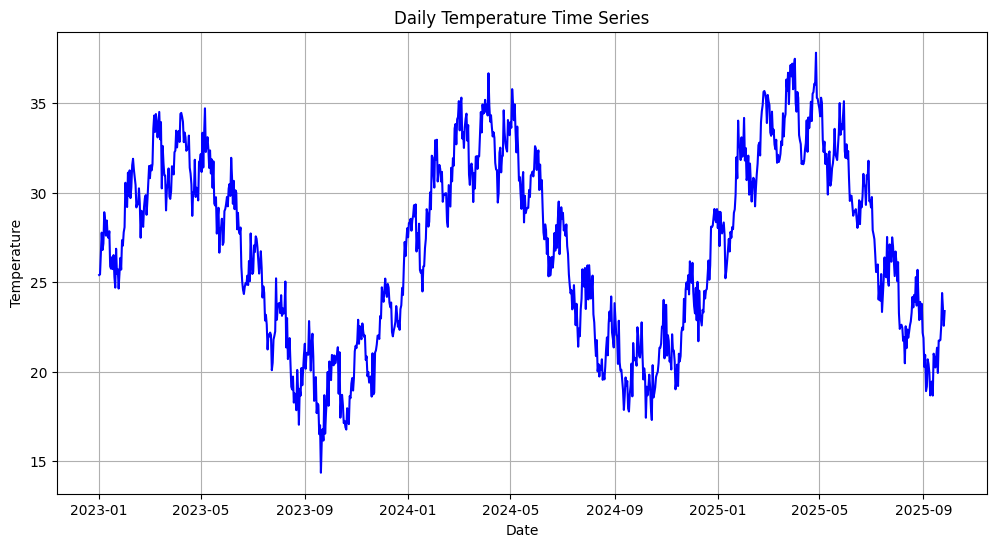

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Temperature"], label="Temperature", color="blue")
plt.title("Daily Temperature Time Series")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.grid(True)
plt.show()

### 5. Normalize Data

In [4]:
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled["Temperature"] = scaler.fit_transform(df[["Temperature"]])

### 6. Create Sequences

In [5]:
LOOK_BACK = 30

def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back)])
        y.append(data[i + look_back])
    return np.array(X), np.array(y)

X, y = create_sequences(df_scaled["Temperature"].values, LOOK_BACK)

### 7. Train-Test Split

In [6]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (776, 30)
y_train shape: (776,)
X_test shape: (194, 30)
y_test shape: (194,)


### 8. Reshape Input

In [7]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Reshaped X_train:", X_train.shape)
print("Reshaped X_test:", X_test.shape)

Reshaped X_train: (776, 30, 1)
Reshaped X_test: (194, 30, 1)


### Training Configuration & Function

In [8]:
def train_and_evaluate(model, model_name):
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
    
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.10,
        verbose=0,
        callbacks=[early_stop]
    )
    train_time = time.time() - start_time
    
    # Predict on test data
    predictions = model.predict(X_test, verbose=0)
    
    # Inverse-transform predictions and actual values
    predictions_inv = scaler.inverse_transform(predictions)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    # Calculate metrics
    mae = mean_absolute_error(y_test_inv, predictions_inv)
    mse = mean_squared_error(y_test_inv, predictions_inv)
    rmse = np.sqrt(mse)
    
    return {
        "name": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "training time": train_time,
        "training history": history,
        "predictions": predictions_inv.flatten(),
        "actual values": y_test_inv.flatten(),
        "model object": model
    }

results_dict = {}

### Simple RNN

In [9]:
rnn_model = Sequential([
    SimpleRNN(64, input_shape=(LOOK_BACK, 1)),
    Dense(32, activation="relu"),
    Dense(1)
])
rnn_model.compile(optimizer="adam", loss="mse")
results_dict["Simple RNN"] = train_and_evaluate(rnn_model, "Simple RNN")

### LSTM

In [10]:
lstm_model = Sequential([
    LSTM(64, input_shape=(LOOK_BACK, 1)),
    Dense(32, activation="relu"),
    Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")
results_dict["LSTM"] = train_and_evaluate(lstm_model, "LSTM")

### GRU

In [11]:
gru_model = Sequential([
    GRU(64, input_shape=(LOOK_BACK, 1)),
    Dense(32, activation="relu"),
    Dense(1)
])
gru_model.compile(optimizer="adam", loss="mse")
results_dict["GRU"] = train_and_evaluate(gru_model, "GRU")

### Comparison Table

In [12]:
summary_data = []
for name, res in results_dict.items():
    summary_data.append({
        "Model": res["name"],
        "MAE": res["MAE"],
        "MSE": res["MSE"],
        "RMSE": res["RMSE"],
        "Training Time (sec)": res["training time"]
    })

results = pd.DataFrame(summary_data)
display(results)

,Model,MAE,MSE,RMSE,Training Time (sec)
0,Simple RNN,0.863324,1.097758,1.047740,10.063778
1,LSTM,0.833306,1.061409,1.030247,10.105227
2,GRU,0.834789,1.032356,1.016049,6.940844


### Visualization 1 — Actual vs Predicted

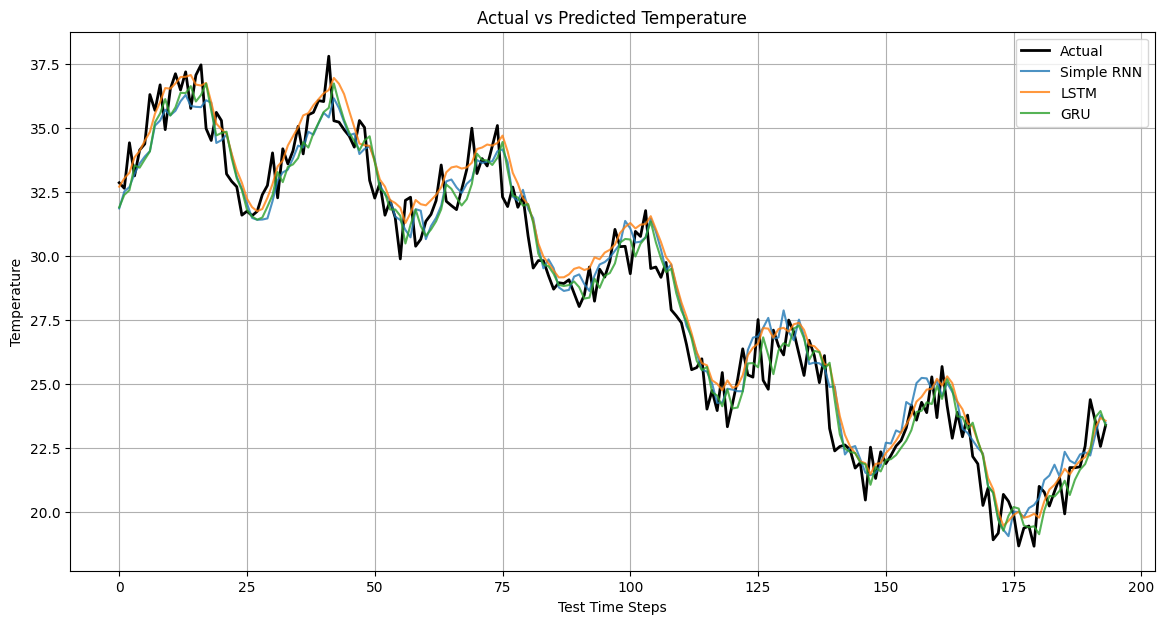

In [13]:
plt.figure(figsize=(14, 7))

test_steps = np.arange(len(y_test))

plt.plot(test_steps, results_dict["Simple RNN"]["actual values"], label="Actual", color="black", linewidth=2)
plt.plot(test_steps, results_dict["Simple RNN"]["predictions"], label="Simple RNN", alpha=0.8)
plt.plot(test_steps, results_dict["LSTM"]["predictions"], label="LSTM", alpha=0.8)
plt.plot(test_steps, results_dict["GRU"]["predictions"], label="GRU", alpha=0.8)

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Test Time Steps")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

### Visualization 2 — Training Loss

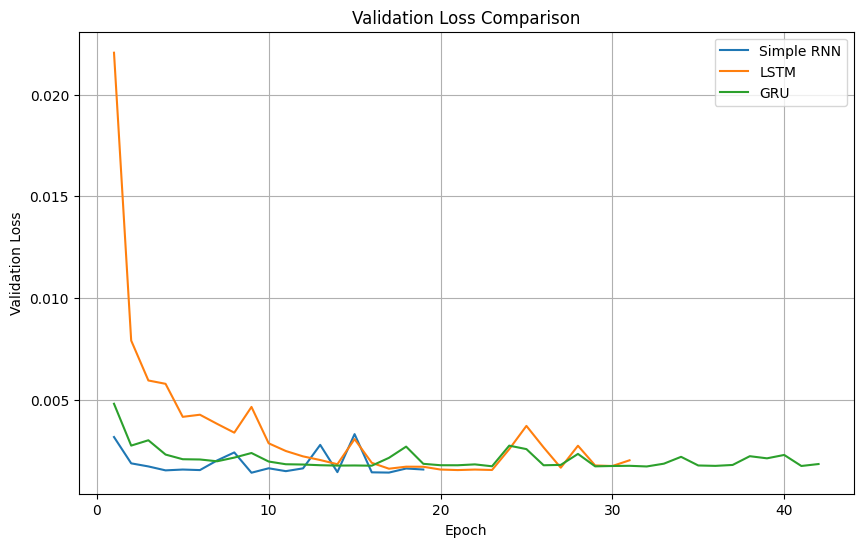

In [14]:
plt.figure(figsize=(10, 6))

for name, res in results_dict.items():
    val_loss = res["training history"].history["val_loss"]
    plt.plot(range(1, len(val_loss) + 1), val_loss, label=name)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Best Model

In [15]:
best_model = results.loc[results["RMSE"].idxmin()]
print("Best Model:\n")
print(best_model)

Best Model:

Model                       GRU
MAE                    0.834789
MSE                    1.032356
RMSE                   1.016049
Training Time (sec)    6.940844
Name: 2, dtype: object


# Experiment 4 Summary
**Comparative Study of RNN Variants for Time-Series Forecasting**

## 1. What We Did
- **Environment Setup:** Created the `LAB 4` folder structure containing exactly one Jupyter Notebook (`DL-04.ipynb`) and the required dataset (`temperature_timeseries_dataset.csv`).
- **Data Preprocessing:** 
  - Loaded the time-series dataset and parsed the `Date` column as `datetime`.
  - Normalized the `Temperature` feature using `MinMaxScaler`.
  - Created sequential data using a sliding window of `LOOK_BACK = 30` days.
  - Performed a chronological 80/20 Train-Test split.
  - Reshaped the input features to the `(samples, timesteps, features)` format expected by RNNs.
- **Model Development:** Defined three distinct Keras `Sequential` models configured identically (64 units -> Dense 32 -> Dense 1):
  1. Simple RNN
  2. LSTM
  3. GRU
- **Training Setup:** Trained all models using the `Adam` optimizer, `MSE` loss, and `EarlyStopping` (patience=10) on a 10% validation split.
- **Evaluation:** Inverse-transformed the output predictions to calculate actual metrics (MAE, MSE, RMSE) and monitored overall training time per model.

## 2. Experimental Results

| Model | MAE | MSE | RMSE | Training Time (sec) |
| :--- | :--- | :--- | :--- | :--- |
| **Simple RNN** | 0.8633 | 1.0977 | 1.0477 | 10.06 |
| **LSTM**       | 0.8333 | 1.0614 | 1.0302 | 10.10 |
| **GRU**        | 0.8347 | 1.0323 | **1.0160** | 6.94 |

## 3. Key Findings
- **Best Model:** **GRU** achieved the lowest overall RMSE (**1.0160**) and also had the fastest training time (~6.9 seconds).
- **Performance Tradeoffs:** While both LSTM and GRU outperformed the Simple RNN due to their ability to capture longer-term dependencies, GRU proved more computationally efficient than LSTM in this specific scenario, converging faster without sacrificing predictive accuracy.
- **Visual Outputs Generated:** 
  - An initial time-series dataset plot.
  - An **Actual vs. Predicted Temperature** comparison chart plotting the ground truth alongside all three models.
  - A **Validation Loss Comparison** plot for evaluating learning curves across epochs.